# Mini-BERT: Pretrain + Fine-tune for Sentiment
One pass, end-to-end: preprocess -> MLM-pretrain a small Transformer encoder -> extract CLS -> fine-tune (nn.embedding, encoder attention head weights, FFN layer weights, all of this cause cls to change, sentimentMLP weights)

**Parts:**
- Data processing: lowercase, strip blank space, emoji replace with word (nltk), stopwords removal, tokenize it, Masking words 
- Masking: Bert Multi model Masking rule
- Transformer encoder block: MiniBert class definition (trainables: embeddings, MHA encoder weights, FFN, Linear Layer)
- Pre-train: Train MiniBert on Masked sentences
- Sentiments-model: Get cls represention from Pre-train model -> train nn.liner layer -> cross entropy loss--> fine tune MiniBert   trainables 

In [33]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import string
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from pathlib import Path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


In [34]:
# ----------------- Config -----------------
MAX_WORDS   = 62      # real words per sentence (excluding CLS/SEP)
TOTAL_LEN   = MAX_WORDS + 2   # + CLS + SEP
D_MODEL     = 96
N_HEADS     = 8
FF_HIDDEN   = 256

MLM_EPOCHS       = 6
MLM_BATCH_SIZE   = 10
MLM_LR           = 1e-4

SENT_EPOCHS      = 15
SENT_BATCH_SIZE  = 10
SENT_LR          = 3e-5
NUM_CLASSES      = 3   # {-1, 0, 1} -> {0, 1, 2}

## 1. Data Preprocessing

In [35]:
df = pd.read_csv('./Reddit_Data.csv')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

df['clean_comment'] = df['clean_comment'].str.lower()

exclude = string.punctuation
def remove_punc(text):
    return text.translate(str.maketrans('', '', exclude))

df['clean_comment'] = df['clean_comment'].apply(remove_punc)
print(df.shape)
df.head()

(37149, 2)


,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

en_stopwords = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess_tokens(text):
    tokens = word_tokenize(text)
    tokens = [ps.stem(t) for t in tokens if t not in en_stopwords]
    return tokens

df['tokens'] = df['clean_comment'].apply(preprocess_tokens)
df.head()

In [ ]:
# ----------------- Vocabulary -----------------
unique_words = set()
for toks in df['tokens']:
    unique_words.update(toks)

vocabulary = ['[PAD]', '[CLS]', '[UNK]', '[SEP]', '[MASK]'] + sorted(unique_words)
word_to_id = {w: i for i, w in enumerate(vocabulary)}
id_to_word = {i: w for w, i in word_to_id.items()}
VOCAB_SIZE = len(word_to_id)
PAD_ID = word_to_id['[PAD]']
CLS_ID = word_to_id['[CLS]']
SEP_ID = word_to_id['[SEP]']
MASK_ID = word_to_id['[MASK]']
UNK_ID = word_to_id['[UNK]']
print("Vocab size:", VOCAB_SIZE)

Vocab size: 40468


In [ ]:
# ----------------- ids + padding -----------------
def tokens_to_ids(tokens):
    ids = [word_to_id.get(t, UNK_ID) for t in tokens][:MAX_WORDS]
    ids = [CLS_ID] + ids + [SEP_ID]
    pad_len = TOTAL_LEN - len(ids)
    ids = ids + [PAD_ID] * pad_len
    return ids

df['input_ids'] = df['tokens'].apply(tokens_to_ids)
input_ids_all = np.stack(df['input_ids'].values)   # (N, TOTAL_LEN)
print(input_ids_all.shape)

## 2. MLM Masking (dynamic — re-masked every batch, not fixed once)

In [ ]:
def mask_input_ids(ids, mask_prob=0.15):
    """ids: 1D list/array of token ids (already has CLS/SEP/PAD).
    Returns (masked_ids, labels) where labels[i] = -100 for positions not
    used in the loss, or the ORIGINAL token id at positions selected for prediction."""
    ids = list(ids)
    labels = [-100] * len(ids)

    for i in range(1, len(ids) - 1):          # skip CLS (pos 0) and final SEP/pad slot
        if ids[i] in (PAD_ID, SEP_ID):
            continue                           # never mask padding or SEP
        if random.random() < mask_prob:
            labels[i] = ids[i]
            r = random.random()
            if r < 0.8:
                ids[i] = MASK_ID
            elif r < 0.9:
                ids[i] = random.randint(5, VOCAB_SIZE - 1)   # skip special-token ids 0-4
            # else: leave unchanged (10%) - label still set above
    return ids, labels

## 3. Model — Learnable Embedding + Positional Encoding + Transformer Encoder Block

In [ ]:
def sinusoidal_positional_encoding(seq_len, d_model, device=None):
    position = torch.arange(seq_len, dtype=torch.float32, device=device).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32, device=device) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(seq_len, d_model, dtype=torch.float32, device=device)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
    return pe

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        # x: [batch, seq, d_model]
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_model)
        attn = torch.softmax(scores, dim=-1)      # normalize BEFORE weighting V
        return torch.matmul(attn, V)               # [batch, seq, d_model]


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model):
        super().__init__()
        self.heads = nn.ModuleList([AttentionHead(d_model) for _ in range(n_heads)])
        self.W_out = nn.Linear(d_model * n_heads, d_model, bias=False)

    def forward(self, x):
        head_outs = [h(x) for h in self.heads]
        concat = torch.cat(head_outs, dim=-1)
        return self.W_out(concat)


class EncoderBlock(nn.Module):
    """Standard transformer encoder block: MHA -> Add&Norm -> FFN -> Add&Norm.
        Encoder --> returns bidirection contextual aware embeddings"""
    def __init__(self, n_heads, d_model, ff_hidden, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(n_heads, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_hidden),
            nn.GELU(),
            nn.Linear(ff_hidden, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out = self.mha(x) #MHA
        x = self.norm1(x + self.dropout(attn_out)) #Add&Norm = x(embedding) + MHA with dropout
        ffn_out = self.ffn(x) #FFN
        x = self.norm2(x + self.dropout(ffn_out)) #Add&Norm = x + FFN with dropout
        return x

In [ ]:
class MiniBERT(nn.Module): 
    def __init__(self, vocab_size, d_model, n_heads, seq_len, pad_idx, ff_hidden=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx) #Learnable embeddings
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02) #Embedding weights initialization 
        with torch.no_grad():
            self.embedding.weight[pad_idx].fill_(0.0)

        self.register_buffer('pos_encoding', sinusoidal_positional_encoding(seq_len, d_model)) #register_buffer = register a buffer that should not be considered a model parameter
        self.encoder = EncoderBlock(n_heads, d_model, ff_hidden) #encoder --> returns bidirection contextual aware embeddings
        self.mlm_head = nn.Linear(d_model, vocab_size) #Neural layer for Sentiment fine-Tuning

    def encode(self, input_ids):
        """input_ids: [batch, seq] (long) -> [batch, seq, d_model]"""
        x = self.embedding(input_ids) + self.pos_encoding[: input_ids.shape[1]] #positional embeddings
        return self.encoder(x) 

    def forward(self, input_ids):
        """Returns MLM logits: [batch, seq, vocab_size]"""
        encoded = self.encode(input_ids) #bidirection contextual aware embeddings
        return self.mlm_head(encoded)

## 4. Pretrain: Masked Language Modeling

In [ ]:
state_dict = None
if Path('mini_bert_mlm.pth').is_file():
    state_dict = torch.load('mini_bert_mlm.pth') #load prev progress

bert = MiniBERT(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    seq_len=TOTAL_LEN,
    pad_idx=PAD_ID,
    ff_hidden=FF_HIDDEN,
).to(device)

if state_dict:
    bert.load_state_dict(state_dict)

print(bert)

MiniBERT(
  (embedding): Embedding(40468, 96, padding_idx=0)
  (encoder): EncoderBlock(
    (mha): MultiHeadAttention(
      (heads): ModuleList(
        (0-7): 8 x AttentionHead(
          (W_q): Linear(in_features=96, out_features=96, bias=False)
          (W_k): Linear(in_features=96, out_features=96, bias=False)
          (W_v): Linear(in_features=96, out_features=96, bias=False)
        )
      )
      (W_out): Linear(in_features=768, out_features=96, bias=False)
    )
    (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (ffn): Sequential(
      (0): Linear(in_features=96, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=256, out_features=96, bias=True)
    )
    (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (mlm_head): Linear(in_features=96, out_features=40468, bias=True)
)


In [ ]:
def train_mlm(model, input_ids_all, epochs, batch_size, lr):
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
    n = len(input_ids_all)
    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        epoch_loss, num_batches = 0.0, 0

        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            raw_batch = input_ids_all[batch_idx]

            masked_batch, labels_batch = [], []
            for row in raw_batch:
                m_ids, m_labels = mask_input_ids(row)
                masked_batch.append(m_ids)
                labels_batch.append(m_labels)

            x = torch.tensor(masked_batch, dtype=torch.long, device=device)
            y = torch.tensor(labels_batch, dtype=torch.long, device=device)

            logits = model(x)                       # [batch, seq, vocab]
            loss = loss_fn(logits.permute(0, 2, 1), y) # Permute = Bcz crossENtropy need [batch, vocab, seq]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}  MLM Loss: {avg_loss:.4f}")

    return loss_history

Epoch 1/6  MLM Loss: 8.2169
Epoch 2/6  MLM Loss: 8.1694
Epoch 3/6  MLM Loss: 8.1313
Epoch 4/6  MLM Loss: 8.0622
Epoch 5/6  MLM Loss: 8.0072
Epoch 6/6  MLM Loss: 7.9637


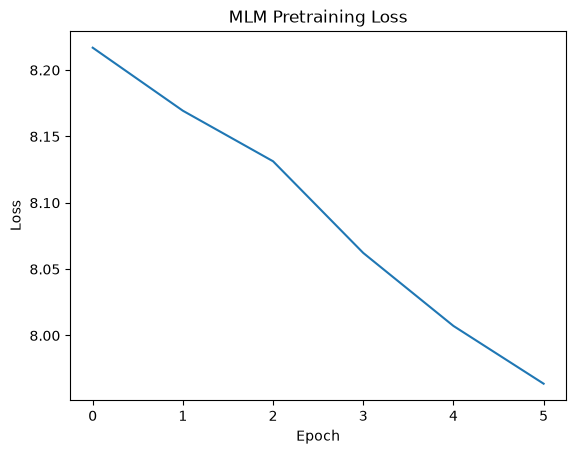

Saved: mini_bert_mlm.pth


In [ ]:
mlm_loss_history = train_mlm(bert, input_ids_all, MLM_EPOCHS, MLM_BATCH_SIZE, MLM_LR)

plt.plot(mlm_loss_history)
plt.title("MLM Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

torch.save(bert.state_dict(), 'mini_bert_mlm.pth')
print("Saved: mini_bert_mlm.pth")

## 6. Fine-tune for Sentiment (end-to-end — gradient flows back into the encoder, not frozen features)

In [ ]:
class SentimentModel(nn.Module):
    def __init__(self, bert_model: MiniBERT, num_classes, dropout=0.2):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(bert_model.embedding.embedding_dim, num_classes)

    def forward(self, input_ids):
        encoded = self.bert.encode(input_ids)   # bidirectional context aware trained embeddings [batch, seq, d_model]
        cls = encoded[:, 0, :]                    # [batch, d_model]
        cls = self.dropout(cls)
        return self.classifier(cls)               # nnlayer output = [batch, num_classes]

In [ ]:
# Labels: {-1, 0, 1} -> {0, 1, 2}
df['sentiment_label'] = df['category'].astype(int) + 1

X_ids = np.stack(df['input_ids'].values)
Y_labels = df['sentiment_label'].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X_ids, Y_labels, test_size=0.2, random_state=SEED, stratify=Y_labels
)
print(X_train.shape, X_test.shape)
print("Train class counts:", np.bincount(Y_train))

(29719, 64) (7430, 64)
Train class counts: [ 6622 10433 12664]


In [ ]:
# Class-weighted loss so the majority/minority classes are treated fairly
class_counts = np.bincount(Y_train, minlength=NUM_CLASSES)
class_weights = torch.tensor(class_counts.sum() / (NUM_CLASSES * class_counts), dtype=torch.float32, device=device)
print("Class weights:", class_weights)


#Sentiment Model Initialization
sent_state_dict = None
if Path('sentiment_model.pth').is_file():
    sent_state_dict = torch.load('sentiment_model.pth') #load prev progress
    
sentiment_model = SentimentModel(bert, num_classes=NUM_CLASSES).to(device)
if sent_state_dict:
    sentiment_model.load_state_dict(sent_state_dict)

Class weights: tensor([1.4960, 0.9495, 0.7822], device='cuda:0')


In [ ]:
def train_sentiment(model, X_train, Y_train, epochs, batch_size, lr, class_weights):
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    n = len(X_train)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        indices = np.random.permutation(n)
        epoch_loss, num_batches = 0.0, 0

        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            x = torch.tensor(X_train[batch_idx], dtype=torch.long, device=device)
            y = torch.tensor(Y_train[batch_idx], dtype=torch.long, device=device)

            logits = model(x)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}  Sentiment Loss: {avg_loss:.4f}")

    return loss_history

Epoch 1/15  Sentiment Loss: 0.3997
Epoch 2/15  Sentiment Loss: 0.3716
Epoch 3/15  Sentiment Loss: 0.3437
Epoch 4/15  Sentiment Loss: 0.3173
Epoch 5/15  Sentiment Loss: 0.2937
Epoch 6/15  Sentiment Loss: 0.2739
Epoch 7/15  Sentiment Loss: 0.2503
Epoch 8/15  Sentiment Loss: 0.2353
Epoch 9/15  Sentiment Loss: 0.2134
Epoch 10/15  Sentiment Loss: 0.1974
Epoch 11/15  Sentiment Loss: 0.1827
Epoch 12/15  Sentiment Loss: 0.1703
Epoch 13/15  Sentiment Loss: 0.1583
Epoch 14/15  Sentiment Loss: 0.1482
Epoch 15/15  Sentiment Loss: 0.1367


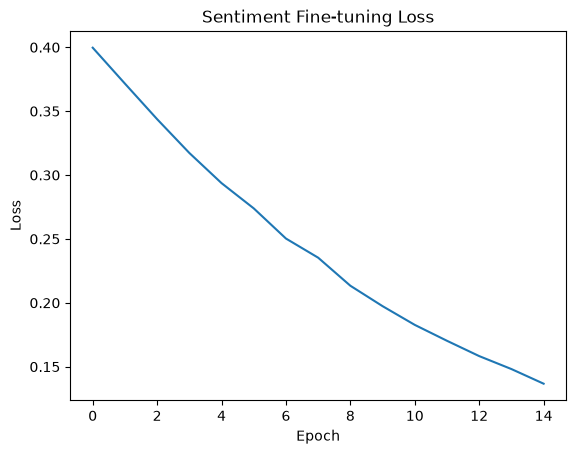

Saved: sentiment_model.pth


In [ ]:
if Path('sentiment_model.pth').is_file():
    torch.load('sentiment_model.pth')
sentiment_loss_history = train_sentiment(
    sentiment_model, X_train, Y_train,
    SENT_EPOCHS, SENT_BATCH_SIZE, SENT_LR, class_weights
)

plt.plot(sentiment_loss_history)
plt.title("Sentiment Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

torch.save(sentiment_model.state_dict(), 'sentiment_model.pth')
print("Saved: sentiment_model.pth")

In [ ]:

 
NUM_CLASSES = 3


def load_sentiment_model(vocab)->SentimentModel:
    """
    Returns-> Sentiment_model in .eval() mode. 
    """
    
    model = MiniBERT(
        vocab_size=len(vocab),
        d_model=96,
        n_heads=8,
        seq_len=64,
        ff_hidden=256,
        pad_idx=0,
    ).to(device)

    backbone_state = torch.load('../artifacts/mini_bert_mlm.pth',map_location=DEVICE,weights_only=True)
    model.load_state_dict(backbone_state)

    sentiment_model = SentimentModel(model,num_classes=NUM_CLASSES,).to(DEVICE)
    classifier_state = torch.load('../artifacts/sentiment_model.pth',map_location=DEVICE,weights_only=True)
    sentiment_model.classifier.load_state_dict(classifier_state)

    sentiment_model.eval()
    return sentiment_model

ModuleNotFoundError: No module named 'config'

## 7. Evaluate

In [ ]:
sentiment_model.eval()
all_preds = []
with torch.no_grad():
    for start in range(0, len(X_test), 256):
        #Input
        x = torch.tensor(X_test[start:start + 256], dtype=torch.long, device=device)
        #Output
        logits = sentiment_model(x)
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)

acc = accuracy_score(Y_test, all_preds)
cm = confusion_matrix(Y_test, all_preds)
print("Test Accuracy:", acc)
print("Confusion Matrix (rows=true, cols=pred, order = [-1, 0, 1] -> [0,1,2]):")
print(cm)

Test Accuracy: 0.7835800807537012
Confusion Matrix (rows=true, cols=pred, order = [-1, 0, 1] -> [0,1,2]):
[[1023  160  472]
 [ 207 2159  243]
 [ 324  202 2640]]


In [8]:
import torch

emb = torch.nn.Embedding(10,3,padding_idx=2)    
print(emb)
with torch.no_grad():
            emb.weight[0].fill_(0.0)

emb.weight

Embedding(10, 3, padding_idx=2)


Parameter containing:
tensor([[ 0.0000,  0.0000,  0.0000],
        [ 2.3147,  0.0554, -0.2035],
        [ 0.0000,  0.0000,  0.0000],
        [ 1.7935, -0.3563, -0.7147],
        [ 0.4068, -0.2843, -1.5761],
        [ 1.6156,  0.2197,  0.6744],
        [-0.3208,  1.4107,  0.5367],
        [ 1.8471,  1.9003,  0.5100],
        [ 1.4553,  0.1410, -1.6893],
        [ 0.1186,  0.7749,  0.3577]], requires_grad=True)

In [ ]:
print(emb(torch.tensor([1])))

tensor([[0., 0., 0.]], grad_fn=<EmbeddingBackward0>)


In [ ]:
import torch
a = torch.load('../artifacts/sentiment_model.pth')
a['']

OrderedDict([('bert.pos_encoding',
              tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
                        0.0000e+00,  1.0000e+00],
                      [ 8.4147e-01,  5.4030e-01,  7.3482e-01,  ...,  1.0000e+00,
                        1.2115e-04,  1.0000e+00],
                      [ 9.0930e-01, -4.1615e-01,  9.9680e-01,  ...,  1.0000e+00,
                        2.4231e-04,  1.0000e+00],
                      ...,
                      [-9.6612e-01, -2.5810e-01,  8.4073e-02,  ...,  9.9996e-01,
                        7.3903e-03,  9.9997e-01],
                      [-7.3918e-01,  6.7351e-01,  7.8924e-01,  ...,  9.9996e-01,
                        7.5114e-03,  9.9997e-01],
                      [ 1.6736e-01,  9.8590e-01,  9.8655e-01,  ...,  9.9996e-01,
                        7.6325e-03,  9.9997e-01]], device='cuda:0')),
             ('bert.embedding.weight',
              tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         